# Семинар 1

## Знакомство с 

![alt text](https://docs.crc.nd.edu/_images/conda.png "Title")

**Сonda** -<br>
система управления пакетами и виртуальными окружениями с открытым исходным кодом

Есть две версии: <br>
**Anaconda** - дистрибутив с кучей предустановленных библиотек для Data Science<br>
**Miniconda** - минимальная версия, содержащая только Conda и Python


Нас устроит версия Miniconda 

# Создадим свое первое окружение 

Набор **must have** команд

In [ ]:
conda create -n first python=3.12
conda activate first
conda deactivate

conda info --envs

conda remove --name first --all

pip install pandas 
pip uninstall pandas 

pip install -r requirements.txt

pip freeze > requirements.txt

# Git 

![alt text](https://media.licdn.com/dms/image/v2/D5612AQGnY3aHlY4wmg/article-cover_image-shrink_720_1280/B56ZbJj36QH0AQ-/0/1747138347502?e=2147483647&v=beta&t=4Lc5lEjJCkvvGZF278-uCD-Ee8XXQVIsdOsNQfu0KY4 "Title")

**Git** - распределенная система контроля и управления версиями кода <br>
**GitHub** - Веб-сервис и крупнейший хостинг для проектов

## Сделаем первый **git clone**

Из него мы сможем получить этот ноутбук и данные для следующих заданий!

In [ ]:
git clone https://github.com/makSShandybo/IGIC_edu

# Задание 1

## Работа с файлами и строками:
У вас есть папка *task_1* где находится набор различных файлов разных разрешений, ваша задача:

- Найти все файлы с расширением **.txt**
- Среди них отфильтровать те, что содержат слово "password" или "secret" в названии.
- В оставшихся **.txt** файлах найти строки, начинающиеся с "DATA:".
- Сохранить найденные данные в итоговый файл extracted_data.txt.

In [5]:
# ШПАРГАЛКА

import os

# 1. Как посмотреть файлы в папке?
files = os.listdir('task_1') 
print(files) # Вернет список имен файлов: ['file1.txt', 'image.jpg']

['notes_temp.txt', 'user_list.csv', 'backup_old.zip', 'image_placeholder.jpg', 'data_log_2025.txt', 'system_dump.bin', 'readme.md', 'todo_list.txt', 'error_report.log', 'output_result.txt', 'config_settings.json', 'secret_passwords.txt']


In [6]:
# 2. Как проверить расширение файла?
filename = "report.txt"
if filename.endswith(".txt"):
    print("Это текстовый файл")

Это текстовый файл


In [7]:
# 3. Как проверить, содержится ли слово в имени файла?
# Используем метод .lower() чтобы поиск не зависел от регистра
if "secret" in filename.lower():
    print("В имени есть слово secret")

In [16]:
# 4. Как прочитать файл построчно?
with open('file.txt', 'r', encoding='utf-8') as f:
    for line in f:
        clean_line = line.strip() # Удаляет пробелы и переносы строк \n
        print(clean_line)

        if clean_line.startswith("123"):
            print(f'Линия которая началась с 123: {clean_line}')

Сохрани меня!
123
Линия которая началась с 123: 123
456
789


In [ ]:
# 5. Как сохранить файл?

text = 'Сохрани меня!'

with open('saved_file.txt', 'w', encoding='utf-8') as f:
    f.write(text)

Этой информации должно быть достаточно, чтобы решить каждый из 4 пунктов

# Ниже находятся ячейки с решением - <br> Давайте договоримся их пока не смотреть :) 

![alt text](https://i.pinimg.com/originals/e1/86/11/e18611dc2ef752b291e3304ae968a81f.gif)

In [27]:
FOLDER_NAME = "task_1" # Имя папки, где лежат файлы

# Получаем список всех имен файлов в папке
all_files = os.listdir(FOLDER_NAME)

print(f"Всего файлов в папке: {len(all_files)}")
print("Список файлов:")
for filename in all_files:
    print(f"- {filename}")

Всего файлов в папке: 12
Список файлов:
- notes_temp.txt
- user_list.csv
- backup_old.zip
- image_placeholder.jpg
- data_log_2025.txt
- system_dump.bin
- readme.md
- todo_list.txt
- error_report.log
- output_result.txt
- config_settings.json
- secret_passwords.txt


In [19]:
txt_files = []

for filename in all_files:
    # Проверяем, заканчивается ли имя файла на .txt
    if filename.endswith('.txt'):
        txt_files.append(filename)

print(f"Найдено .txt файлов: {len(txt_files)}")
print(txt_files)

Найдено .txt файлов: 5
['notes_temp.txt', 'data_log_2025.txt', 'todo_list.txt', 'output_result.txt', 'secret_passwords.txt']


In [24]:
# Создаем список для файлов, прошедших отбор
safe_txt_files = []

for filename in txt_files:
    # Приводим имя к нижнему регистру 
    lower_name = filename.lower()
    
    # Если в имени НЕТ запрещенных слов, добавляем в список безопасных
    if "secret" not in lower_name and "password" not in lower_name:
        safe_txt_files.append(filename)

    else:
        print(f"[ИСКЛЮЧЕНО] {filename} (подозрительное имя)")

print(f"Безопасных файлов: {len(safe_txt_files)}")
print(safe_txt_files)

[ИСКЛЮЧЕНО] secret_passwords.txt (подозрительное имя)
Безопасных файлов: 4
['notes_temp.txt', 'data_log_2025.txt', 'todo_list.txt', 'output_result.txt']


In [26]:
# Сюда будем складывать найденные полезные строки
extracted_lines = []

for filename in safe_txt_files:
    # Формируем полный путь к файлу
    filepath = os.path.join(FOLDER_NAME, filename)
    # filepath = FOLDER_NAME + '/' + filename

    with open(filepath, 'r', encoding='utf-8') as f:
        file_found_something = False
        
        # Читаем файл построчно
        for line in f:
            clean_line = line.strip() # Убираем пробелы и \n
            
            # Проверяем начало строки
            if clean_line.startswith("DATA:"):
                extracted_lines.append(clean_line)

                print(f"[УСПЕХ] {filepath}: найдены данные")


print(f"Всего строк извлечено: {len(extracted_lines)}")
print(extracted_lines)

[УСПЕХ] task_1/notes_temp.txt: найдены данные
[УСПЕХ] task_1/data_log_2025.txt: найдены данные
[УСПЕХ] task_1/data_log_2025.txt: найдены данные
[УСПЕХ] task_1/todo_list.txt: найдены данные
[УСПЕХ] task_1/output_result.txt: найдены данные
[УСПЕХ] task_1/output_result.txt: найдены данные
Всего строк извлечено: 6
['DATA: Meeting at 5PM', 'DATA: Temperature=25C', 'DATA: Pressure=1013hPa', 'DATA: Priority=High', 'DATA: Result=SUCCESS', 'DATA: Code=200']


In [28]:
OUTPUT_FILE = "extracted_data.txt" 

with open(OUTPUT_FILE, 'w', encoding='utf-8') as out_f:
    # Пишем заголовок
    out_f.write("# Результаты парсинга\n")
    
    # Пишем каждую строку
    for line in extracted_lines:
        out_f.write(line + "\n")
        
print(f"Готово! Результат сохранен в файл '{OUTPUT_FILE}'")

# Для проверки выведем содержимое сразу
print("\n--- Содержимое файла ---")
with open(OUTPUT_FILE, 'r', encoding='utf-8') as f:
    print(f.read())

Готово! Результат сохранен в файл 'extracted_data.txt'

--- Содержимое файла ---
# Результаты парсинга
DATA: Meeting at 5PM
DATA: Temperature=25C
DATA: Pressure=1013hPa
DATA: Priority=High
DATA: Result=SUCCESS
DATA: Code=200



## Победа!

![alt text](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQjAGEkJkLp1rSHmggA5VAAXFQ_A2zrYCwyBA&s)

# Теперь решим задачу поинтереснее -
Представим, что у нас есть несколько PDF-файлов статей, а мы хотим извлечь из них только таблицы и ничего больше.


Как же это сделать?

В первую очередь - идем в интернет, скорее всего, кто-то уже решил эту задачу до нас!

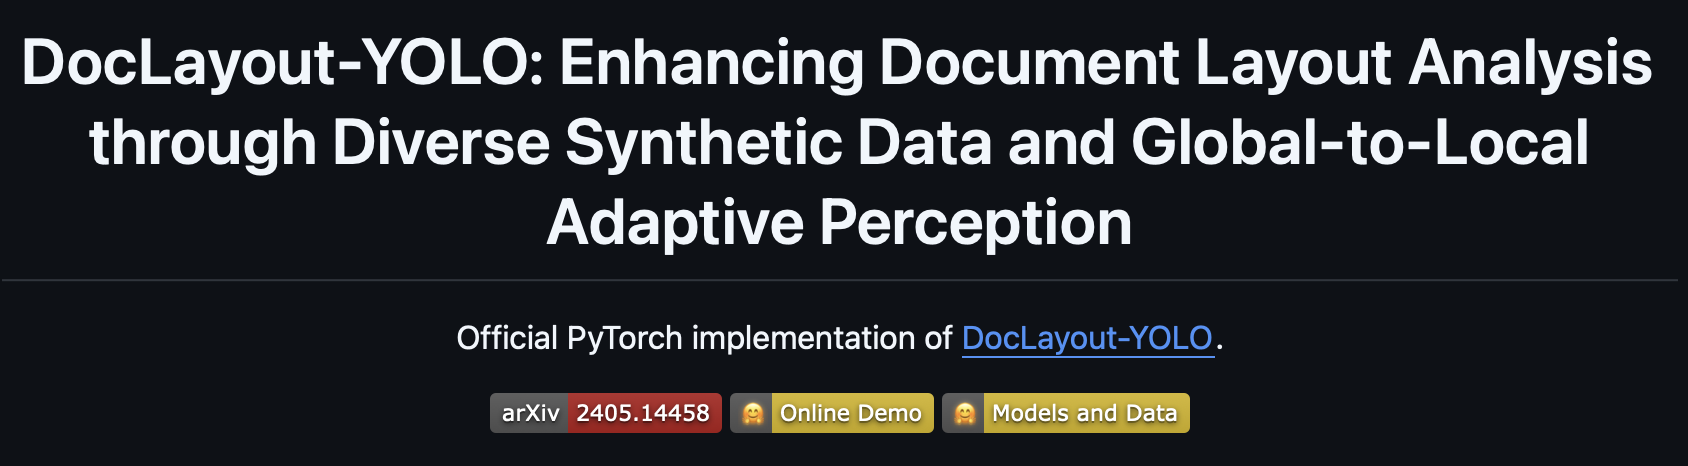

Какое совпадение!

А теперь внимательно изучим репозиторий и найдем все, что нас интересует - <br>

https://github.com/opendatalab/DocLayout-YOLO

In [ ]:
pip install doclayout-yolo

Не забываем скачать веса для модели!

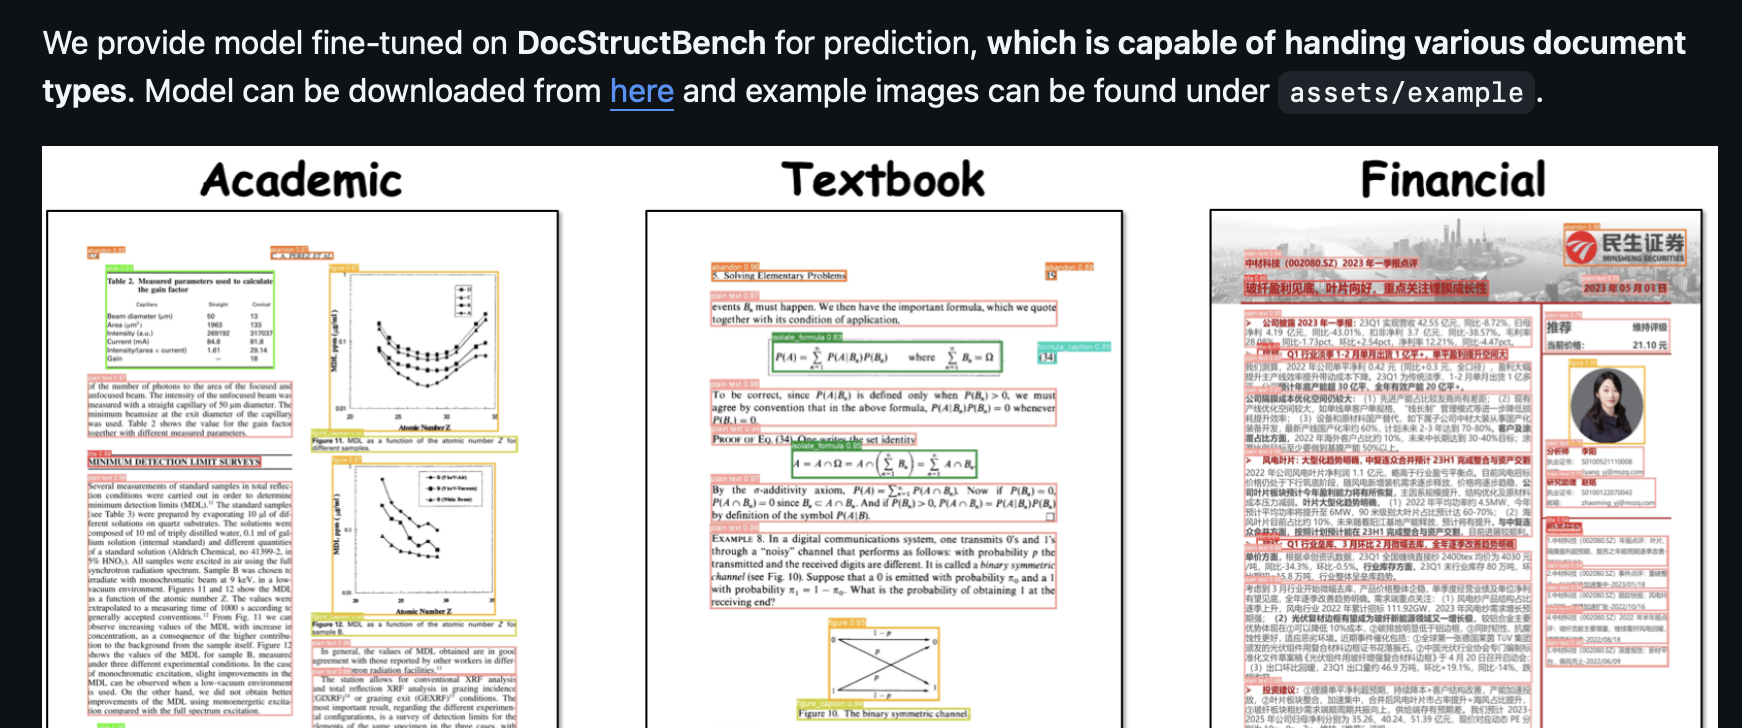

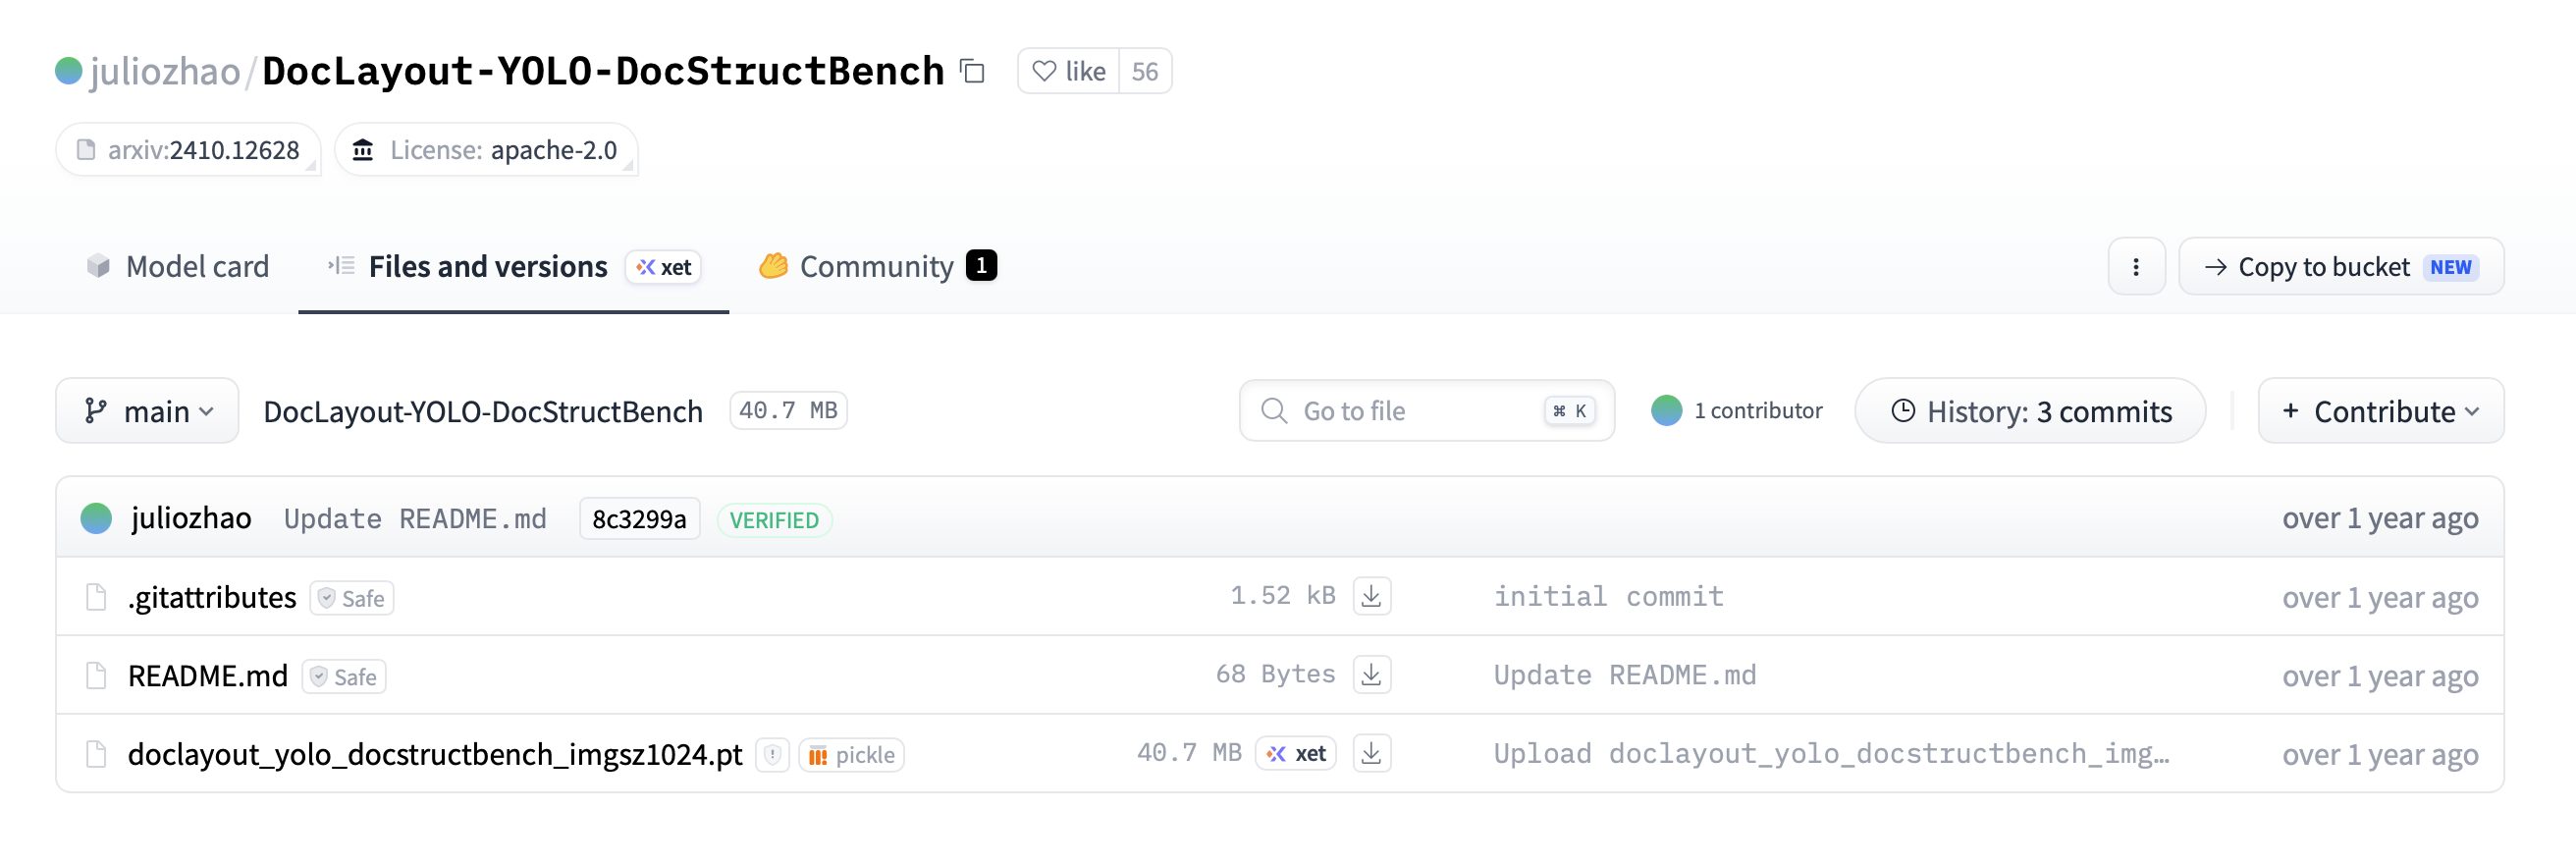

Пример для использования в терминале:

In [ ]:
python demo.py --model path/to/model --image-path path/to/image 

Работаем в ноутбуке:

In [ ]:
import cv2
from doclayout_yolo import YOLOv10

# Load the pre-trained model
model = YOLOv10("task_2/doclayout_yolo_docstructbench_imgsz1024.pt")

# Perform prediction
det_res = model.predict(
    "task_2/test.jpeg",   # Image to predict
    imgsz=1024,        # Prediction image size
    conf=0.2,          # Confidence threshold
    device="cpu"    # Device to use (e.g., 'cuda:0' or 'cpu')
)

# Annotate and save the result
annotated_frame = det_res[0].plot(pil=True, line_width=5, font_size=20)
cv2.imwrite("task_2/result.jpg", annotated_frame)

Doclayout-YOLO принимает на вход изображения, а не PDF - исправим это!

In [ ]:
pip install pdf2image

In [ ]:
from pdf2image import convert_from_path

pdf_path = 'task_2/1.pdf'
images = convert_from_path(pdf_path, dpi=300) # Получили список изображений в формате PIL

In [ ]:
res = model.predict(images) # Сразу даем их на вход YOLO и получаем список результатов


0: 1024x736 1 title, 7 plain texts, 5 abandons, 1 table, 1 table_caption, 1 table_footnote, 1098.4ms
1: 1024x736 5 plain texts, 8 abandons, 2 figures, 3 figure_captions, 1 table, 1 table_caption, 1 table_footnote, 1098.4ms
2: 1024x736 7 plain texts, 8 abandons, 1 figure, 2 tables, 2 table_captions, 1 table_footnote, 1098.4ms
3: 1024x736 2 titles, 12 plain texts, 7 abandons, 1098.4ms
Speed: 4.9ms preprocess, 1098.4ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 736)


In [31]:
res[0]

doclayout_yolo.engine.results.Results object with attributes:

boxes: doclayout_yolo.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'title', 1: 'plain text', 2: 'abandon', 3: 'figure', 4: 'figure_caption', 5: 'table', 6: 'table_caption', 7: 'table_footnote', 8: 'isolate_formula', 9: 'formula_caption'}
obb: None
orig_img: array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [25

In [19]:
res[0].show()

In [28]:
res[0].names

{0: 'title',
 1: 'plain text',
 2: 'abandon',
 3: 'figure',
 4: 'figure_caption',
 5: 'table',
 6: 'table_caption',
 7: 'table_footnote',
 8: 'isolate_formula',
 9: 'formula_caption'}

In [ ]:
res[0].boxes

doclayout_yolo.engine.results.Boxes object with attributes:

cls: tensor([1., 1., 1., 1., 0., 2., 1., 5., 2., 2., 6., 1., 2., 2., 7., 1.])
conf: tensor([0.9786, 0.9759, 0.9710, 0.9701, 0.9554, 0.9422, 0.9253, 0.8908, 0.8363, 0.8329, 0.7607, 0.6513, 0.6194, 0.5432, 0.5377, 0.4930])
data: tensor([[1.2799e+03, 1.4014e+03, 2.2901e+03, 2.4213e+03, 9.7860e-01, 1.0000e+00],
        [1.2807e+03, 2.4265e+03, 2.2890e+03, 3.1081e+03, 9.7587e-01, 1.0000e+00],
        [1.9275e+02, 1.4992e+03, 1.2011e+03, 2.3745e+03, 9.7100e-01, 1.0000e+00],
        [1.9297e+02, 2.3802e+03, 1.2027e+03, 2.5699e+03, 9.7006e-01, 1.0000e+00],
        [1.9392e+02, 1.1184e+03, 1.1089e+03, 1.3307e+03, 9.5537e-01, 0.0000e+00],
        [1.9362e+02, 2.6443e+03, 1.2017e+03, 3.1073e+03, 9.4215e-01, 2.0000e+00],
        [1.9232e+02, 1.3546e+03, 9.3047e+02, 1.4486e+03, 9.2526e-01, 1.0000e+00],
        [1.2242e+03, 2.8475e+02, 2.3506e+03, 1.0283e+03, 8.9075e-01, 5.0000e+00],
        [2.2094e+03, 3.1605e+03, 2.2840e+03, 3.1947e+03,

In [33]:
import os
import cv2

def save_tables_from_results(results, save_dir="cropped_tables", class_id=5):
    """
    Принимает список результатов YOLO (results), находит объекты заданного класса
    и сохраняет их кропы в одну папку.
    """
    # Создаем папку 
    os.makedirs(save_dir, exist_ok=True)

    # 1. Проходим по каждому результату (каждому исходному изображению)
    for idx, res in enumerate(results):
        img = res.orig_img
        boxes = res.boxes
            
        # 2. Проходим по всем боксам внутри текущего изображения
        # Используем zip для одновременного перебора классов и координат
        for cls_id, xyxy in zip(boxes.cls, boxes.xyxy):
            
            # Фильтр по классу (5 - table)
            if int(cls_id) == class_id:
                # Координаты в формате [x1, y1, x2, y2]
                x1, y1, x2, y2 = map(int, xyxy.tolist())
                
                # Вырезаем область (slicing: [y_start:y_end, x_start:x_end])
                crop = img[y1:y2, x1:x2]
                
                # Формируем уникальное имя файла
                # table_0.jpg, table_1.jpg ...
                filename = f"table_{idx}.jpg"
                filepath = os.path.join(save_dir, filename)
                
                # Сохраняем
                cv2.imwrite(filepath, crop)
            

save_tables_from_results(res, save_dir="task_2/all_tables_output")

# Теперь у нас есть папка со всеми таблицами из данного PDF!

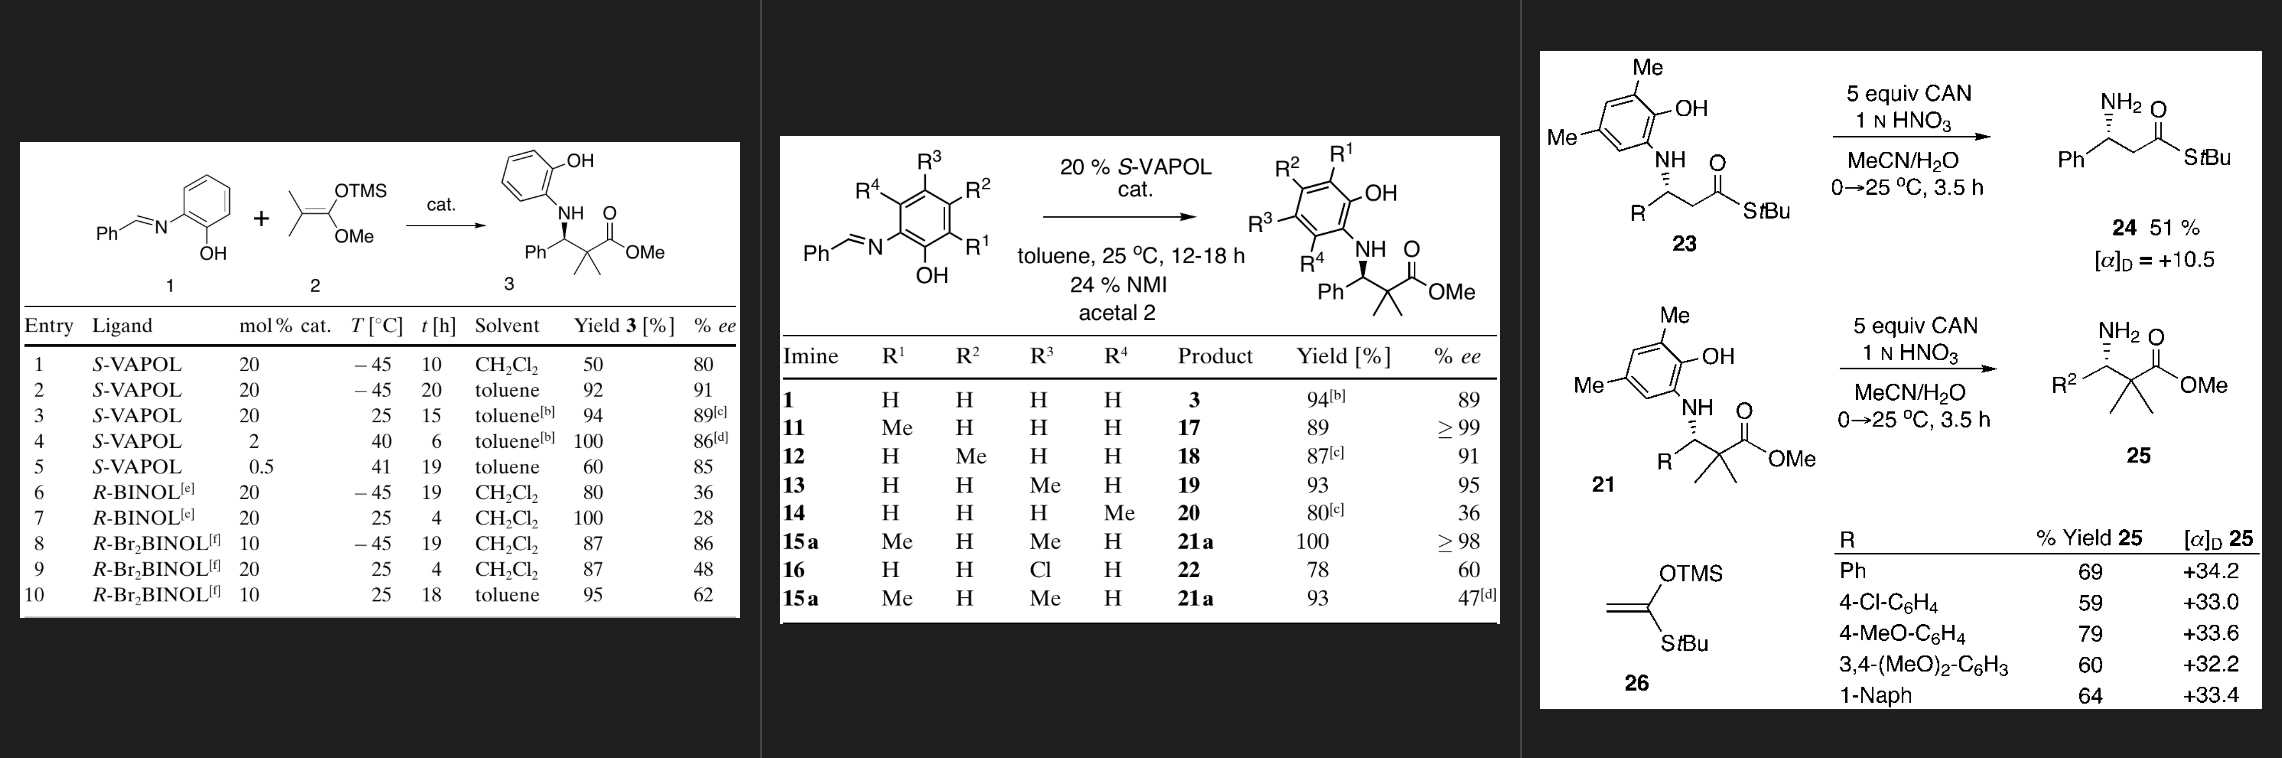